# PHẦN 1: CÀI ĐẶT & IMPORT

In [ ]:
!pip install -U spacy
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

import spacy
import random
import math
import time
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# NLTK cho BLEU score
import nltk
from nltk.translate.bleu_score import corpus_bleu

# Thiết lập Seed
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--> Đang chạy trên thiết bị: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 110.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 131.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
--> Đang chạy trên thiết bị: cuda


# PHẦN 2: CHUẨN BỊ DỮ LIỆU RAW

In [ ]:
if not os.path.exists('multi30k-dataset'):
    print("--> Đang tải dataset từ GitHub...")
    !git clone https://github.com/multi30k/dataset.git multi30k-dataset

DATA_DIR = 'multi30k-dataset/data/task1/raw'

def read_raw_data(base_path, filename):
    gz_path = os.path.join(base_path, filename + '.gz')
    txt_path = os.path.join(base_path, filename)

    if os.path.exists(gz_path):
        with gzip.open(gz_path, 'rt', encoding='utf-8') as f:
            return [line.strip() for line in f]
    elif os.path.exists(txt_path):
        with open(txt_path, 'r', encoding='utf-8') as f:
            return [line.strip() for line in f]
    else:
        if 'test' in filename:
            alt_name = 'test_2016_flickr.en' if 'en' in filename else 'test_2016_flickr.fr'
            alt_path = os.path.join(base_path, alt_name + '.gz')
            if os.path.exists(alt_path):
                with gzip.open(alt_path, 'rt', encoding='utf-8') as f:
                    return [line.strip() for line in f]
        raise FileNotFoundError(f"Không tìm thấy file {filename}")

print("--> Đang đọc dữ liệu Raw...")
train_src = read_raw_data(DATA_DIR, 'train.en')
train_trg = read_raw_data(DATA_DIR, 'train.fr')
val_src = read_raw_data(DATA_DIR, 'val.en')
val_trg = read_raw_data(DATA_DIR, 'val.fr')
test_src = read_raw_data(DATA_DIR, 'test.en')
test_trg = read_raw_data(DATA_DIR, 'test.fr')

print(f"Train size: {len(train_src)}")

--> Đang tải dataset từ GitHub...
Cloning into 'multi30k-dataset'...
remote: Enumerating objects: 313, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 313 (delta 17), reused 21 (delta 16), pack-reused 281 (from 1)
Receiving objects: 100% (313/313), 18.21 MiB | 31.81 MiB/s, done.
Resolving deltas: 100% (69/69), done.
--> Đang đọc dữ liệu Raw...
Train size: 29000


# PHẦN 3: TOKENIZATION & VOCAB (Tự triển khai - KHÔNG DÙNG TORCHTEXT)

In [ ]:
# Load Spacy models
spacy_en = spacy.load('en_core_web_sm')
spacy_fr = spacy.load('fr_core_news_sm')

def tokenize_en(text):
    return [tok.text for tok in spacy_en.tokenizer(text)]

def tokenize_fr(text):
    return [tok.text for tok in spacy_fr.tokenizer(text)]

# Class Vocab tự viết (thay thế build_vocab_from_iterator)
class Vocab:
    def __init__(self, token_to_idx, idx_to_token):
        self.stoi = token_to_idx
        self.itos = idx_to_token
        self.unk_index = self.stoi['<unk>']

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.unk_index)

    def lookup_token(self, idx):
        return self.itos[idx]

def build_vocab(data, tokenizer, max_size=10000, min_freq=2):
    counter = Counter()
    for text in data:
        counter.update(tokenizer(text))

    # Các token đặc biệt
    specials = ['<unk>', '<pad>', '<sos>', '<eos>']

    # Lấy các từ phổ biến nhất
    most_common = counter.most_common(max_size - len(specials))

    # Tạo dictionary mapping
    token_to_idx = {token: i for i, token in enumerate(specials)}
    idx_to_token = {i: token for i, token in enumerate(specials)}

    curr_idx = len(specials)
    for token, freq in most_common:
        if freq >= min_freq:
            token_to_idx[token] = curr_idx
            idx_to_token[curr_idx] = token
            curr_idx += 1

    return Vocab(token_to_idx, idx_to_token)

print("--> Đang xây dựng từ điển (Cách thủ công, không lỗi version)...")
# Xây dựng từ điển
vocab_src = build_vocab(train_src, tokenize_en, max_size=10000)
vocab_trg = build_vocab(train_trg, tokenize_fr, max_size=10000)

UNK_IDX = vocab_src['<unk>']
PAD_IDX = vocab_src['<pad>']
SOS_IDX = vocab_src['<sos>']
EOS_IDX = vocab_src['<eos>']

print(f"Vocab EN: {len(vocab_src)} | Vocab FR: {len(vocab_trg)}")

--> Đang xây dựng từ điển (Cách thủ công, không lỗi version)...
Vocab EN: 6191 | Vocab FR: 6555


# PHẦN 4: DATASET & DATALOADER

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, src_data, trg_data, src_vocab, trg_vocab, src_tokenizer, trg_tokenizer):
        self.src_data = src_data
        self.trg_data = trg_data
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        src_text = self.src_data[idx]
        trg_text = self.trg_data[idx]

        src_tokens = [self.src_vocab[token] for token in self.src_tokenizer(src_text)]
        trg_tokens = [self.trg_vocab[token] for token in self.trg_tokenizer(trg_text)]

        return (torch.tensor([SOS_IDX] + src_tokens + [EOS_IDX], dtype=torch.long),
                torch.tensor([SOS_IDX] + trg_tokens + [EOS_IDX], dtype=torch.long))

def collate_fn(batch):
    # Sort giảm dần để pack_padded_sequence hoạt động
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    src_batch, trg_batch = zip(*batch)

    src_lens = torch.tensor([len(x) for x in src_batch])
    src_padded = pad_sequence(src_batch, padding_value=PAD_IDX)
    trg_padded = pad_sequence(trg_batch, padding_value=PAD_IDX)

    return src_padded, trg_padded, src_lens

BATCH_SIZE = 128
train_dataset = TranslationDataset(train_src, train_trg, vocab_src, vocab_trg, tokenize_en, tokenize_fr)
val_dataset = TranslationDataset(val_src, val_trg, vocab_src, vocab_trg, tokenize_en, tokenize_fr)
test_dataset = TranslationDataset(test_src, test_trg, vocab_src, vocab_trg, tokenize_en, tokenize_fr)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# PHẦN 5: MÔ HÌNH (Encoder-Decoder LSTM)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_len):
        embedded = self.dropout(self.embedding(src))
        packed_embedded = pack_padded_sequence(embedded, src_len.to('cpu'), enforce_sorted=True)
        packed_outputs, (hidden, cell) = self.rnn(packed_embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(0))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, src_len, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        hidden, cell = self.encoder(src, src_len)
        input = trg[0, :]
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[t] if teacher_force else top1
        return outputs

INPUT_DIM = len(vocab_src)
OUTPUT_DIM = len(vocab_trg)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device).to(device)

def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(6191, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(6555, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (fc_out): Linear(in_features=512, out_features=6555, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

# PHẦN 6: HUẤN LUYỆN

--> Bắt đầu huấn luyện...
Epoch 1: Val Loss giảm (4.884) -> Đã lưu model.
	Train Loss: 5.007 | Val Loss: 4.884
Epoch 2: Val Loss giảm (4.578) -> Đã lưu model.
	Train Loss: 4.247 | Val Loss: 4.578
Epoch 3: Val Loss giảm (4.317) -> Đã lưu model.
	Train Loss: 3.851 | Val Loss: 4.317
Epoch 4: Val Loss giảm (4.068) -> Đã lưu model.
	Train Loss: 3.524 | Val Loss: 4.068
Epoch 5: Val Loss giảm (3.979) -> Đã lưu model.
	Train Loss: 3.246 | Val Loss: 3.979
Epoch 6: Val Loss giảm (3.784) -> Đã lưu model.
	Train Loss: 2.996 | Val Loss: 3.784
Epoch 7: Val Loss không giảm (1/3)
	Train Loss: 2.805 | Val Loss: 3.796
Epoch 8: Val Loss giảm (3.596) -> Đã lưu model.
	Train Loss: 2.619 | Val Loss: 3.596
Epoch 9: Val Loss giảm (3.552) -> Đã lưu model.
	Train Loss: 2.471 | Val Loss: 3.552
Epoch 10: Val Loss giảm (3.404) -> Đã lưu model.
	Train Loss: 2.323 | Val Loss: 3.404
Epoch 11: Val Loss không giảm (1/3)
	Train Loss: 2.191 | Val Loss: 3.448
Epoch 12: Val Loss giảm (3.347) -> Đã lưu model.
	Train Loss: 2

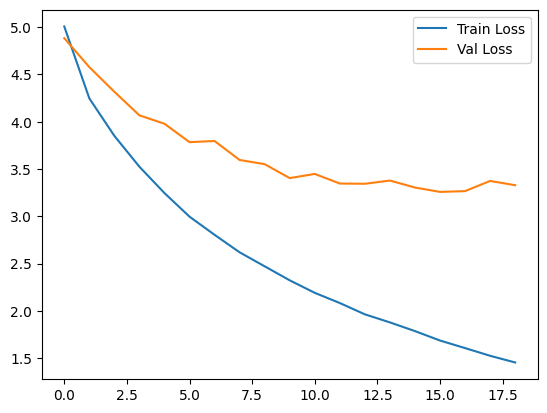

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    for i, (src, trg, src_len) in enumerate(iterator):
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        output = model(src, trg, src_len)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, (src, trg, src_len) in enumerate(iterator):
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, src_len, teacher_forcing_ratio=0)
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(iterator)

N_EPOCHS = 20
CLIP = 1
PATIENCE = 3
best_valid_loss = float('inf')
patience_counter = 0
train_losses = []
valid_losses = []

print("--> Bắt đầu huấn luyện...")
for epoch in range(N_EPOCHS):
    start_time = time.time()
    train_loss = train(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, val_loader, criterion)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
        print(f"Epoch {epoch+1}: Val Loss giảm ({valid_loss:.3f}) -> Đã lưu model.")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1}: Val Loss không giảm ({patience_counter}/{PATIENCE})")

    print(f'\tTrain Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}')

    if patience_counter >= PATIENCE:
        print("--> Dừng sớm (Early Stopping)!")
        break

plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Val Loss')
plt.legend()
plt.show()

# PHẦN 7: ĐÁNH GIÁ & TRANSLATE

In [ ]:
def translate(sentence_str, max_len=50):
    model.eval()
    tokens = tokenize_en(sentence_str)
    tokens = ['<sos>'] + tokens + ['<eos>']
    src_indexes = [vocab_src[token] for token in tokens]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(1).to(device)
    src_len = torch.LongTensor([len(src_indexes)])

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor, src_len)

    trg_indexes = [vocab_trg['<sos>']]
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        with torch.no_grad():
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell)
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)
        if pred_token == vocab_trg['<eos>']:
            break

    trg_tokens = [vocab_trg.lookup_token(i) for i in trg_indexes]
    return " ".join(trg_tokens[1:-1])

def calculate_bleu(data, model, device):
    trgs = []
    pred_trgs = []
    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    print("--> Đang tính BLEU trên tập Test...")
    for src, trg in zip(data.src_data, data.trg_data):
        pred_sentence = translate(src)
        pred_tokens = pred_sentence.split()
        trg_tokens = tokenize_fr(trg)
        pred_trgs.append(pred_tokens)
        trgs.append([trg_tokens])
    return corpus_bleu(trgs, pred_trgs) * 100

try:
    bleu_score = calculate_bleu(test_dataset, model, device)
    print(f'BLEU score = {bleu_score:.2f}')
except Exception as e:
    print(f"Lỗi tính BLEU: {e}")

print("\n=== DEMO DỊCH THUẬT ===")
indices = [10, 50, 100]
for i in indices:
    if i < len(test_src):
        src = test_src[i]
        trg = test_trg[i]
        pred = translate(src)
        print(f"En: {src}")
        print(f"Fr: {pred}")
        print("-" * 30)

--> Đang tính BLEU trên tập Test...
BLEU score = 32.93

=== DEMO DỊCH THUẬT ===
En: A mother and her young song enjoying a beautiful day outside.
Fr: Une mère et son fils se amusant à une journée ensoleillée .
------------------------------
En: People walking down sidewalk next to a line of stores.
Fr: Des gens marchant sur le trottoir à côté d' un stand de restauration .
------------------------------
En: A happy woman is preparing a refreshment at a coffee shop.
Fr: Une femme amish prépare un repas dans un café .
------------------------------
